In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("loan_data.csv")
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,male,Associate,47971,6,RENT,15000,MEDICAL,15.66,0.31,3,645,No,1
44996,37,female,Associate,65800,17,RENT,9000,HOMEIMPROVEMENT,14.07,0.14,11,621,No,1
44997,33,male,Associate,56942,7,RENT,2771,DEBTCONSOLIDATION,10.02,0.05,10,668,No,1
44998,29,male,Bachelor,33164,4,RENT,12000,EDUCATION,13.23,0.36,6,604,No,1


In [3]:
cat_cols = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

In [4]:
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [5]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,0,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,0,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,3,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,0,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,1,3,35000,3,14.27,0.53,4,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,6,3,15000,3,15.66,0.31,3,645,0,1
44996,37,0,0,65800,17,3,9000,2,14.07,0.14,11,621,0,1
44997,33,1,0,56942,7,3,2771,0,10.02,0.05,10,668,0,1
44998,29,1,1,33164,4,3,12000,1,13.23,0.36,6,604,0,1


In [6]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  int64  
 2   person_education                45000 non-null  int64  
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  int64  
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  int64  
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

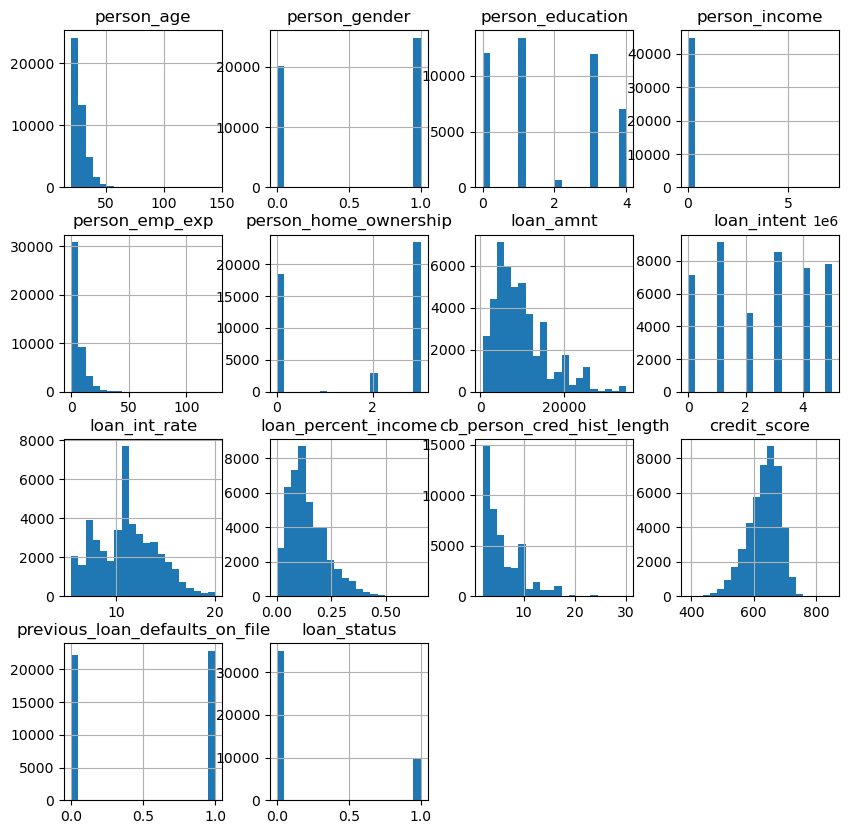

In [8]:
import matplotlib.pyplot as plt
df.hist(bins=20, figsize=(10, 10))
plt.show()

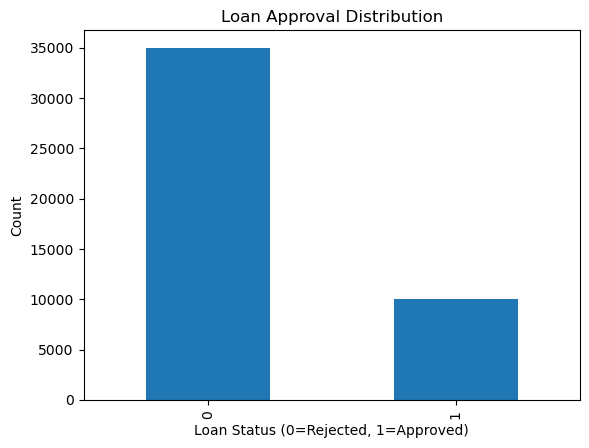

In [9]:
df['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (0=Rejected, 1=Approved)")
plt.ylabel("Count")
plt.show()

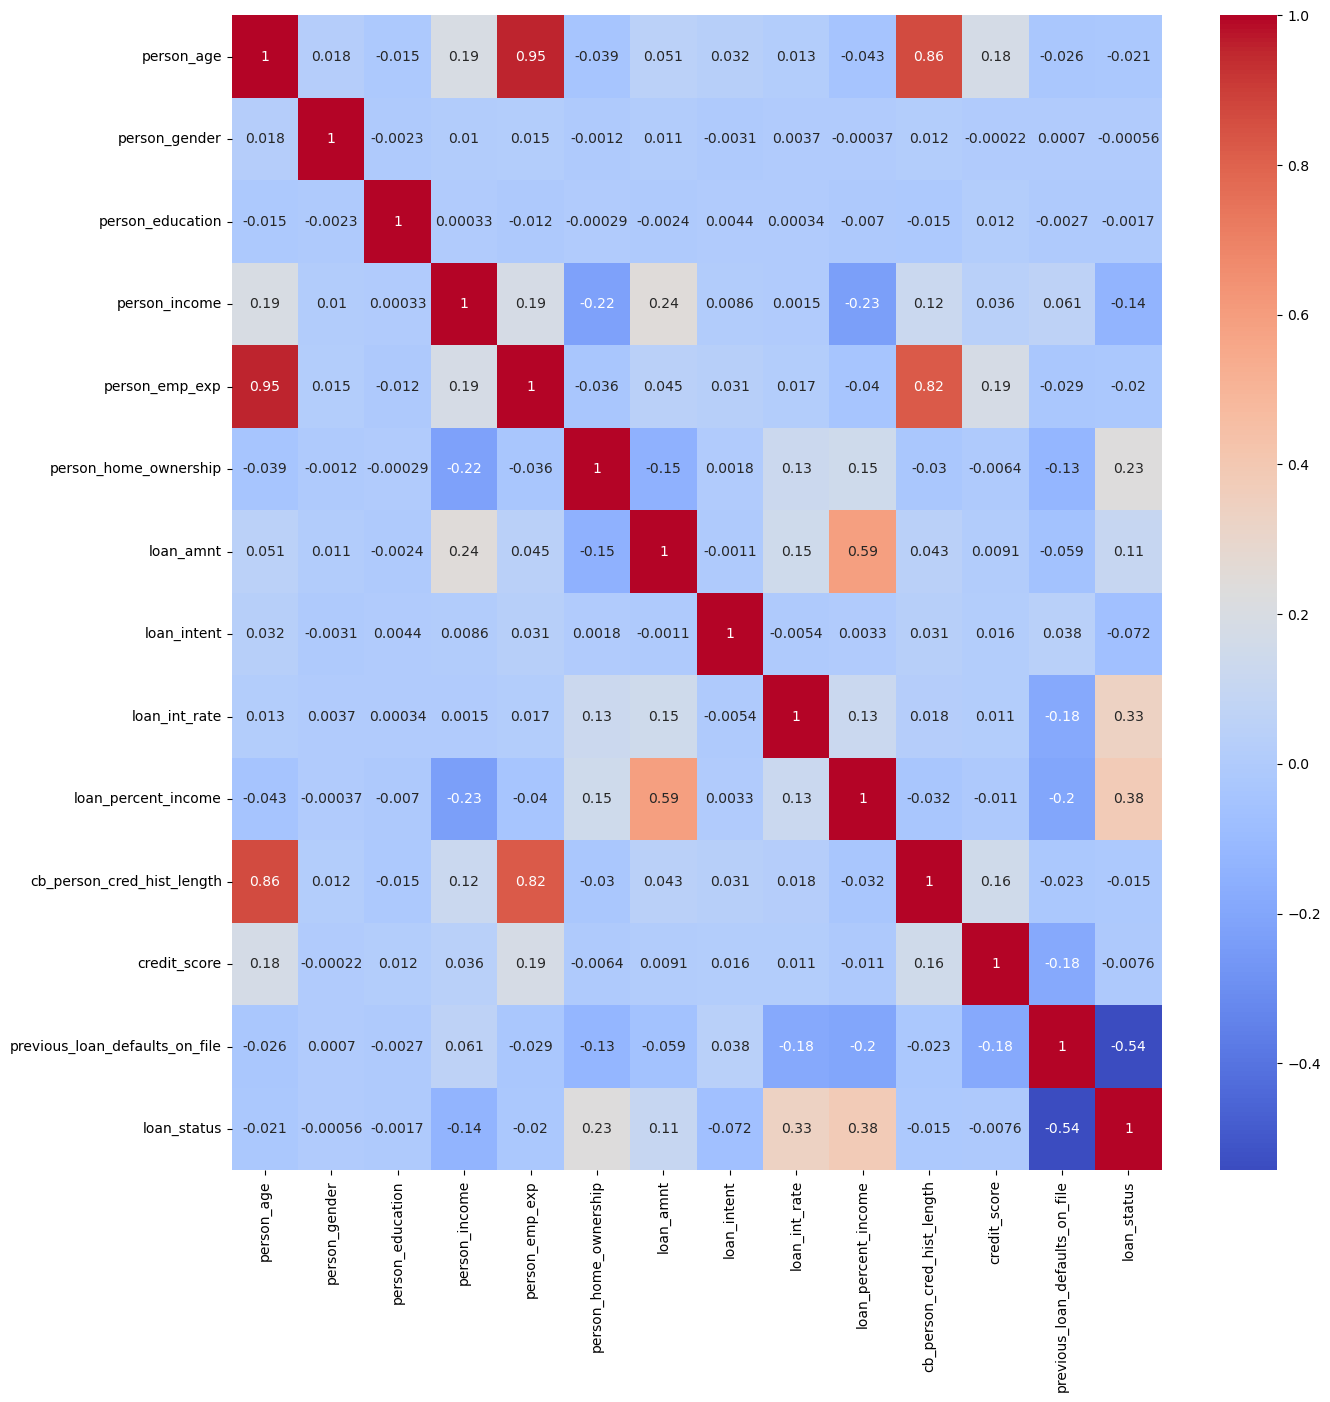

In [10]:
import seaborn as sb
plt.figure(figsize=(15, 15))
sb.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [11]:
df.drop(columns = ['person_emp_exp'], inplace=True)
df

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,3,35000,4,16.02,0.49,3,561,0,1
1,21,0,3,12282,2,1000,1,11.14,0.08,2,504,1,0
2,25,0,3,12438,0,5500,3,12.87,0.44,3,635,0,1
3,23,0,1,79753,3,35000,3,15.23,0.44,2,675,0,1
4,24,1,4,66135,3,35000,3,14.27,0.53,4,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,3,645,0,1
44996,37,0,0,65800,3,9000,2,14.07,0.14,11,621,0,1
44997,33,1,0,56942,3,2771,0,10.02,0.05,10,668,0,1
44998,29,1,1,33164,3,12000,1,13.23,0.36,6,604,0,1


In [12]:
df.drop(columns = ['cb_person_cred_hist_length'], inplace=True)
df

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,loan_status
0,22,0,4,71948,3,35000,4,16.02,0.49,561,0,1
1,21,0,3,12282,2,1000,1,11.14,0.08,504,1,0
2,25,0,3,12438,0,5500,3,12.87,0.44,635,0,1
3,23,0,1,79753,3,35000,3,15.23,0.44,675,0,1
4,24,1,4,66135,3,35000,3,14.27,0.53,586,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,645,0,1
44996,37,0,0,65800,3,9000,2,14.07,0.14,621,0,1
44997,33,1,0,56942,3,2771,0,10.02,0.05,668,0,1
44998,29,1,1,33164,3,12000,1,13.23,0.36,604,0,1


In [13]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [14]:
X

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file
0,22,0,4,71948,3,35000,4,16.02,0.49,561,0
1,21,0,3,12282,2,1000,1,11.14,0.08,504,1
2,25,0,3,12438,0,5500,3,12.87,0.44,635,0
3,23,0,1,79753,3,35000,3,15.23,0.44,675,0
4,24,1,4,66135,3,35000,3,14.27,0.53,586,0
...,...,...,...,...,...,...,...,...,...,...,...
44995,27,1,0,47971,3,15000,3,15.66,0.31,645,0
44996,37,0,0,65800,3,9000,2,14.07,0.14,621,0
44997,33,1,0,56942,3,2771,0,10.02,0.05,668,0
44998,29,1,1,33164,3,12000,1,13.23,0.36,604,0


In [15]:
y

0        1
1        0
2        1
3        1
4        1
        ..
44995    1
44996    1
44997    1
44998    1
44999    1
Name: loan_status, Length: 45000, dtype: int64

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation="sigmoid", input_shape=(X_train.shape[1],)),
    Dense(32, activation="sigmoid"),
    Dense(16, activation="sigmoid"),
    Dense(1, activation="sigmoid")
])


C:\Users\Daksh\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8425 - loss: 0.3538 - val_accuracy: 0.8889 - val_loss: 0.2511
Epoch 2/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8880 - loss: 0.2470 - val_accuracy: 0.8915 - val_loss: 0.2394
Epoch 3/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8897 - loss: 0.2391 - val_accuracy: 0.8915 - val_loss: 0.2328
Epoch 4/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8900 - loss: 0.2353 - val_accuracy: 0.8924 - val_loss: 0.2302
Epoch 5/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8910 - loss: 0.2325 - val_accuracy: 0.8911 - val_loss: 0.2290
Epoch 6/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8916 - loss: 0.2308 - val_accuracy: 0.8935 - val_loss: 0.2257
Epoch 7/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8939 - loss: 0.2287 - val_accuracy: 0.8943 - val_loss: 0.2236
Epoch 8/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8932 - loss: 0.2269 - val_accuracy: 0.

In [20]:
train_acc = history.history['accuracy'][-1]
print("Training Accuracy:", train_acc)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Training Accuracy: 0.9107638597488403
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9103 - loss: 0.1980
Test Accuracy: 0.9103333353996277


282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      6990
           1       0.85      0.72      0.78      2010

    accuracy                           0.91      9000
   macro avg       0.89      0.84      0.86      9000
weighted avg       0.91      0.91      0.91      9000

Precision: 0.8540317834020011
Recall: 0.7218905472636816


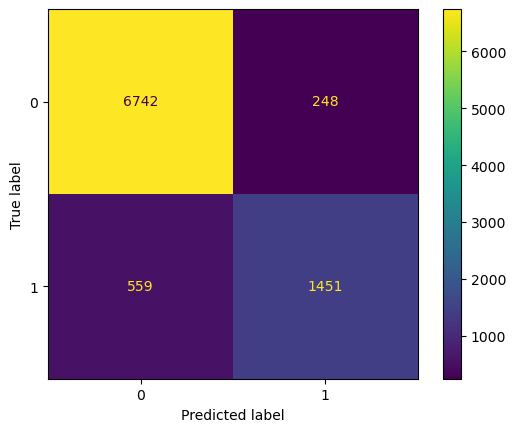

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, precision_score, recall_score
y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("\nClassification Report:\n",classification_report(y_test, y_pred))
print("Precision:", precision)
print("Recall:", recall)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [22]:
X.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate',
       'loan_percent_income', 'credit_score',
       'previous_loan_defaults_on_file'],
      dtype='object')